# Customer Profiling — Identifying Unprofitable Policyholders

**Course:** Statistical Consulting (KU Leuven)
**Approach:** Frequency-severity GLM decomposition with risk-tier profiling

We model claim probability and claim cost separately, then multiply to get
the **pure premium** — the expected loss per policy. Customers whose pure
premium far exceeds the portfolio average are the "unprofitable" profiles
management wants to identify. All reusable logic lives in `src/`; this
notebook focuses on narrative and results.

$$\widehat{\text{Pure Premium}}(\mathbf{x})
   = \underbrace{\hat{p}(\mathbf{x})}_{\text{frequency}}
   \;\times\;
   \underbrace{\hat{\mu}(\mathbf{x})}_{\text{severity}}$$

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import (
    data_loader, eda, preprocessing,
    frequency_model, severity_model,
    pure_premium, profiling, plots,
    style,
)
from src.config import FREQ_TARGET, SEV_TARGET

# Activate the Anthropic warm palette globally
style.apply_warm_theme()

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

---
## 1. Data Loading & Exploration

We have two datasets from the same car-insurance portfolio (2009–2010) that
**cannot be linked at the individual level**:

| Dataset | Records | Target | Description |
|---|---|---|---|
| `frequency.csv` | 24,774 | `claimNumbMD` (0/1) | Did the policy have a claim? |
| `severity.csv`  | 12,256 | `claimSizeMD` (EUR) | Total claim cost (claims only) |

### 1.1 Loading and schema checks

In [2]:
freq_df = data_loader.load_frequency()
sev_df  = data_loader.load_severity()

print(data_loader.quick_summary(freq_df, "frequency"))
print(data_loader.quick_summary(sev_df,  "severity"))
freq_df.head()

frequency: 24,774 rows x 11 cols | missing values: 0 | dtypes: {dtype('int64'): np.int64(4), CategoricalDtype(categories=['2009', '2010'], ordered=False, categories_dtype=str): np.int64(1), CategoricalDtype(categories=['Female', 'Male'], ordered=False, categories_dtype=str): np.int64(1), CategoricalDtype(categories=['A', 'B', 'C', 'D', 'E'], ordered=False, categories_dtype=str): np.int64(1), CategoricalDtype(categories=['Small', 'Medium', 'Large'], ordered=False, categories_dtype=str): np.int64(1), CategoricalDtype(categories=['Employed', 'Housewife', 'Retired', 'Self-employed', 'Unemployed'], ordered=False, categories_dtype=str): np.int64(1), CategoricalDtype(categories=[0, 1], ordered=False, categories_dtype=int64): np.int64(1), dtype('float64'): np.int64(1)}
severity: 12,252 rows x 11 cols | missing values: 0 | dtypes: {dtype('int64'): np.int64(4), CategoricalDtype(categories=['2009', '2010'], ordered=False, categories_dtype=str): np.int64(1), CategoricalDtype(categories=['Female', 

,uwYear,gender,carType,carCat,job,age,nYears,carVal,cover,density,claimNumbMD
0,2009,Male,C,Large,Employed,25,3,15080,0,72.012883,1
1,2009,Male,E,Large,Employed,20,2,22370,1,39.550411,1
2,2009,Female,E,Large,Unemployed,42,0,39650,0,169.529148,1
3,2009,Female,C,Medium,Housewife,21,0,12600,1,58.894688,1
4,2009,Female,D,Large,Employed,33,10,9065,0,109.631885,1


### 1.2 Frequency EDA

Key checks: class balance, mean claim-rate per factor level, and numeric
covariate trends. The goal is to anticipate which covariates will be
significant before we fit the model.

In [3]:
print(f"Overall claim rate: {freq_df[FREQ_TARGET].mean():.3f}")
print(freq_df[FREQ_TARGET].value_counts().rename("count").to_string())

Overall claim rate: 0.496
claimNumbMD
0    12497
1    12277


In [4]:
freq_factor_table = eda.factor_target_table(freq_df, FREQ_TARGET)
freq_factor_table

,variable,level,n,mean_target
0,uwYear,2009,12187,0.484204
1,uwYear,2010,12587,0.506554
2,gender,Female,8474,0.462945
3,gender,Male,16300,0.512515
4,carType,A,6535,0.459526
5,carType,B,5285,0.482308
6,carType,C,3470,0.494813
7,carType,D,5082,0.512593
8,carType,E,4402,0.545888
9,carCat,Small,7595,0.549967


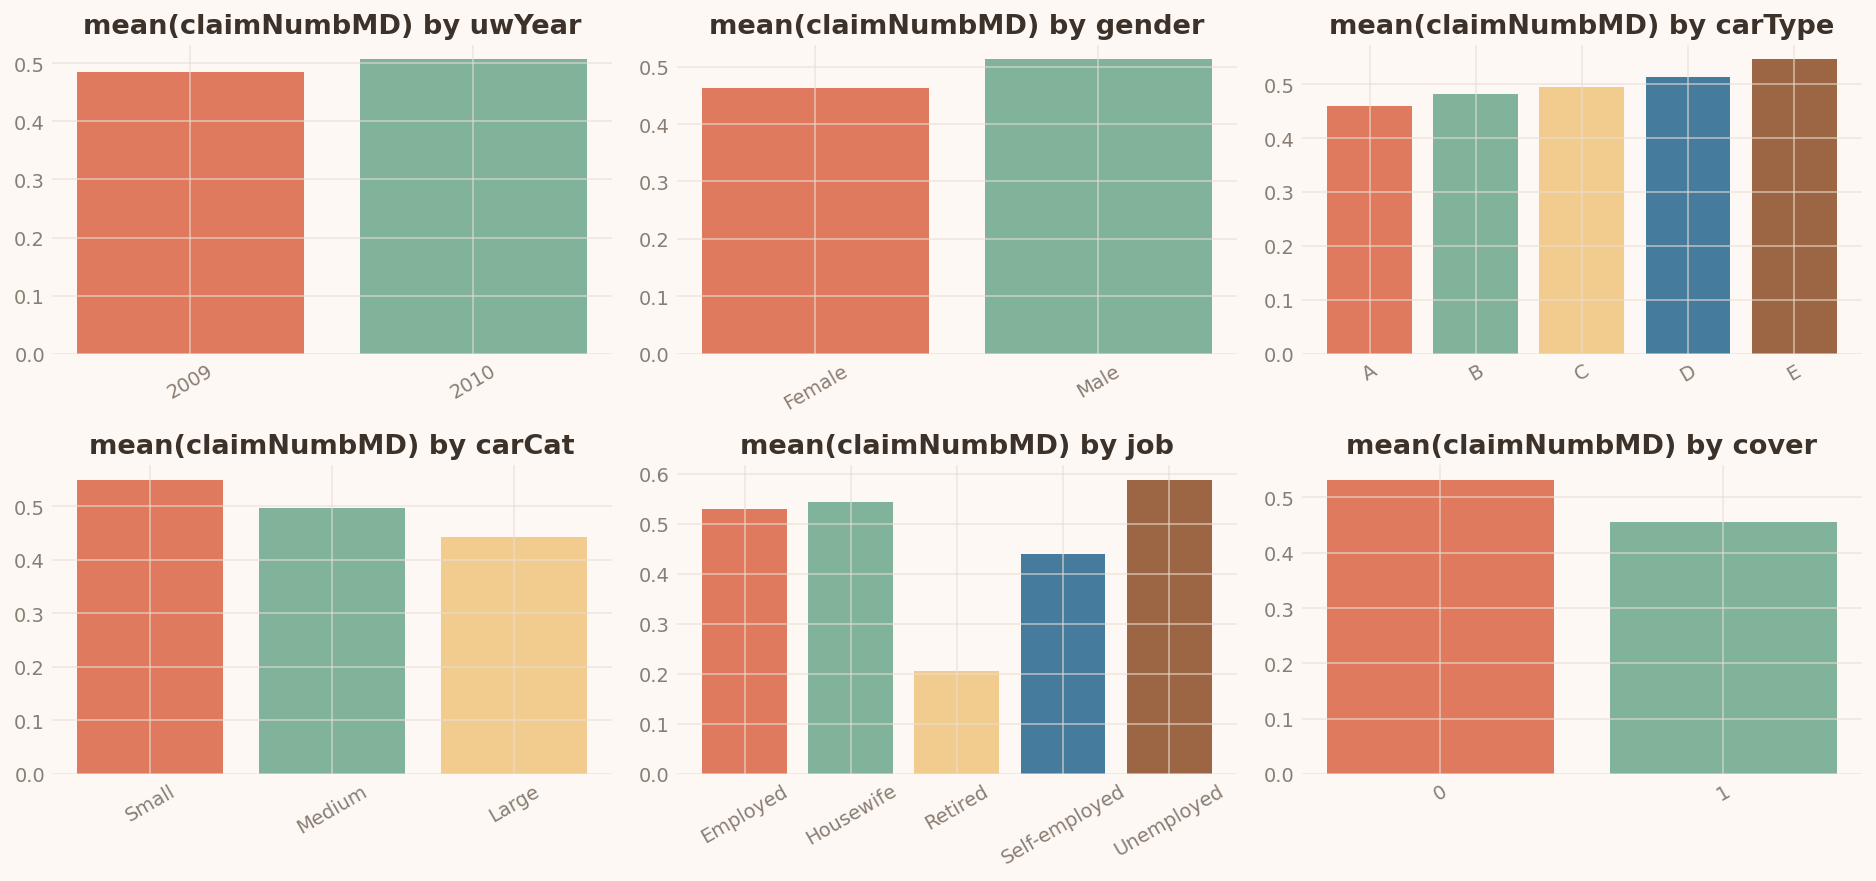

In [5]:
fig = eda.plot_categorical_target(freq_df, FREQ_TARGET); plt.show()

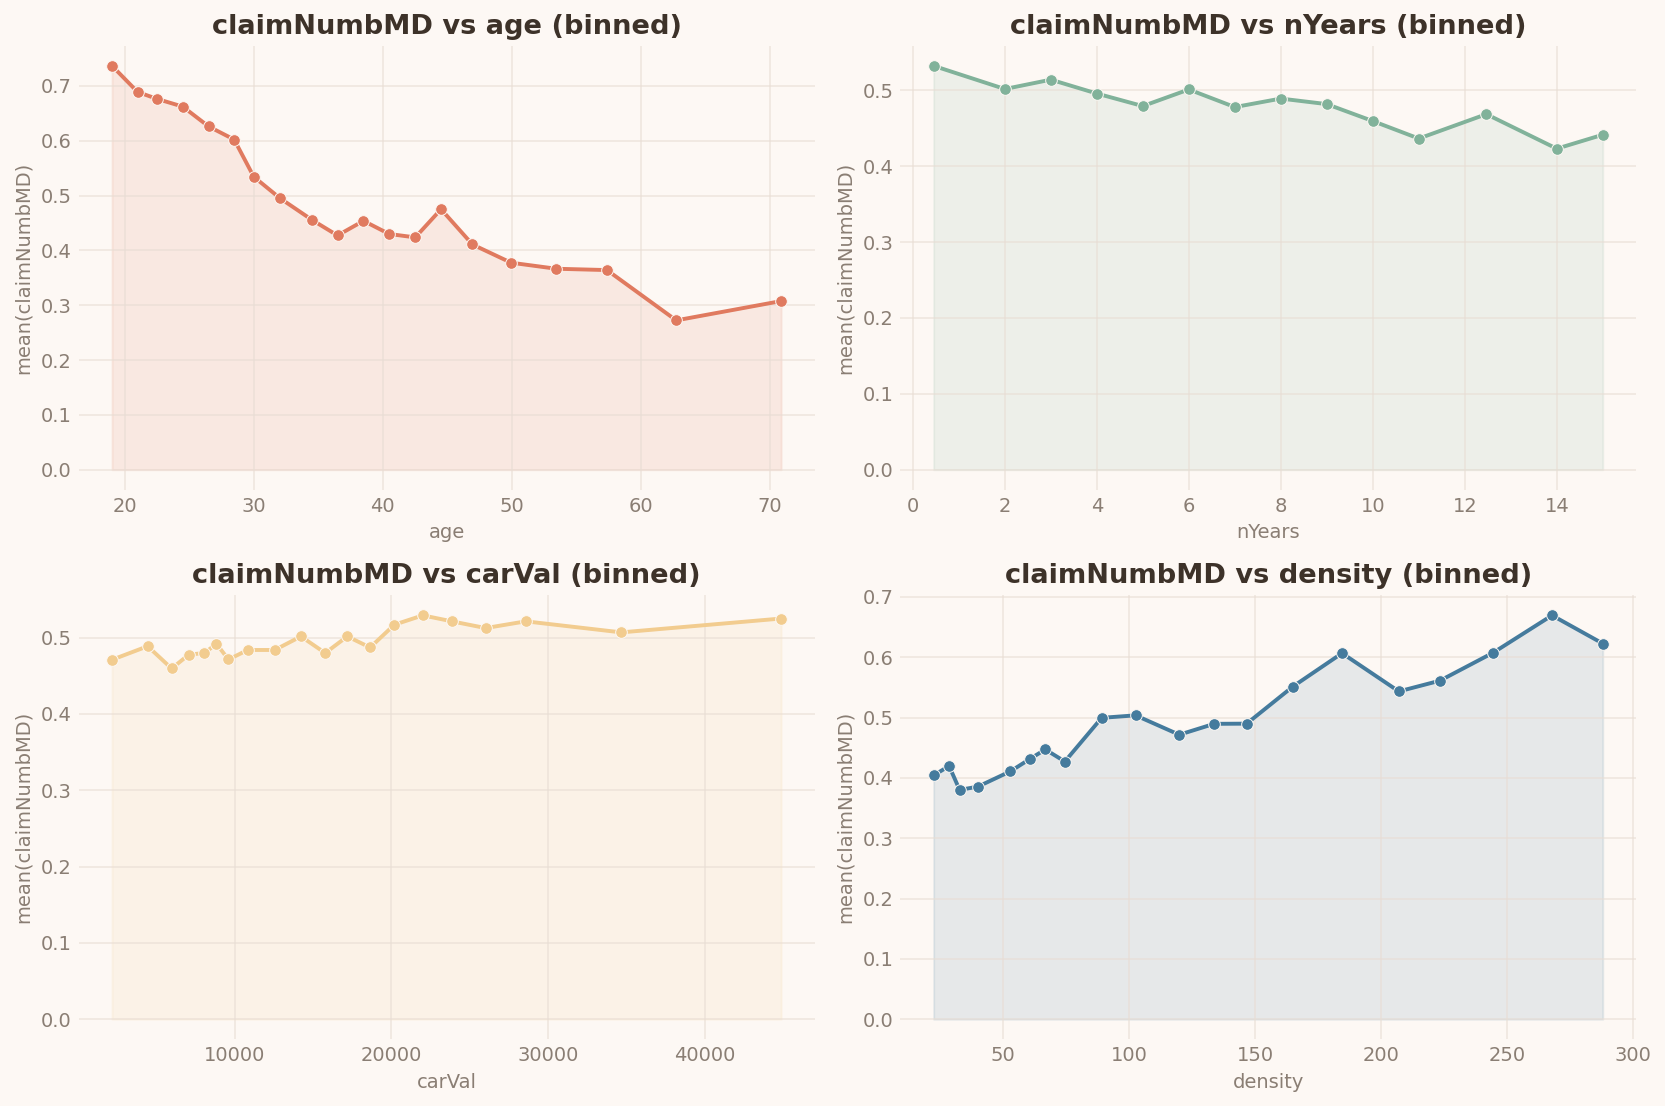

In [6]:
fig = eda.plot_numeric_target(freq_df, FREQ_TARGET); plt.show()

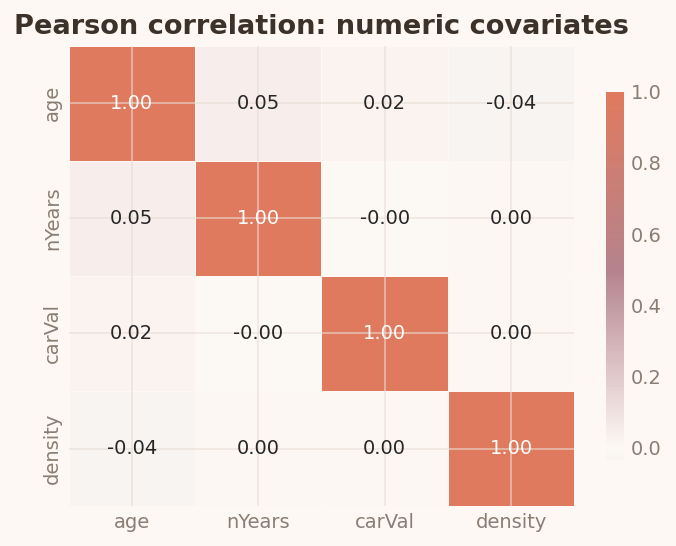

In [7]:
fig = eda.correlation_heatmap(freq_df); plt.show()

### 1.3 Severity EDA

Severity data is **conditional on a claim** — only policies that had at
least one accident appear here. The cost distribution is heavily
right-skewed, so we use a log axis.

In [8]:
print(sev_df[SEV_TARGET].describe().round(1).to_string())

count    12252.0
mean       866.4
std        978.5
min          1.0
25%        228.0
50%        563.0
75%       1154.2
max      12878.0


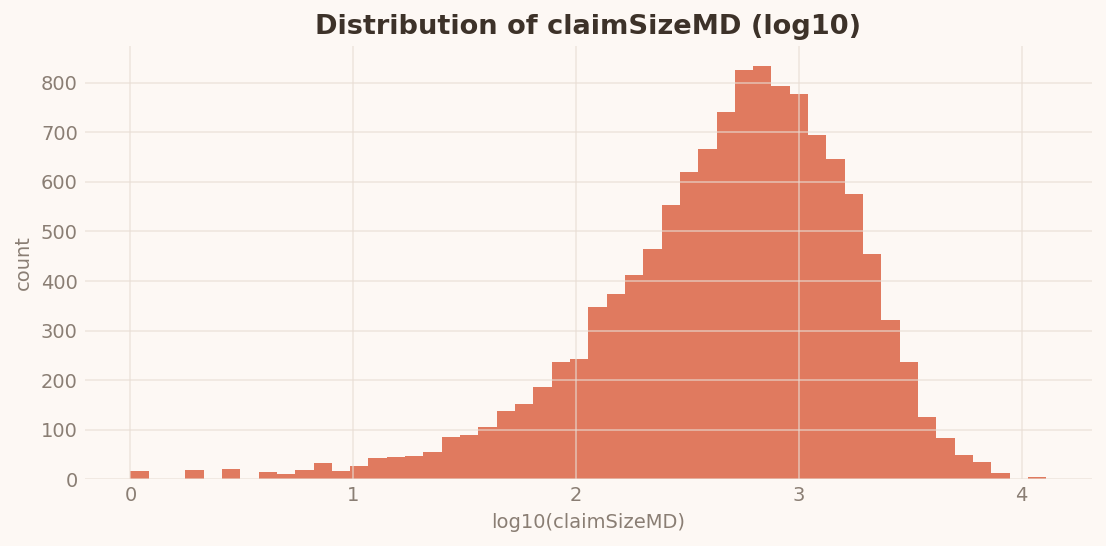

In [9]:
fig = eda.plot_target_distribution(sev_df, SEV_TARGET, log_scale=True); plt.show()

In [10]:
sev_factor_table = eda.factor_target_table(sev_df, SEV_TARGET)
sev_factor_table

,variable,level,n,mean_target
0,uwYear,2009,5879,838.447865
1,uwYear,2010,6373,892.278519
2,gender,Female,3912,792.662321
3,gender,Male,8340,901.058873
4,carType,A,2996,964.899533
5,carType,B,2547,926.173930
6,carType,C,1712,847.279206
7,carType,D,2597,785.612630
8,carType,E,2400,781.310000
9,carCat,Small,4166,902.250840


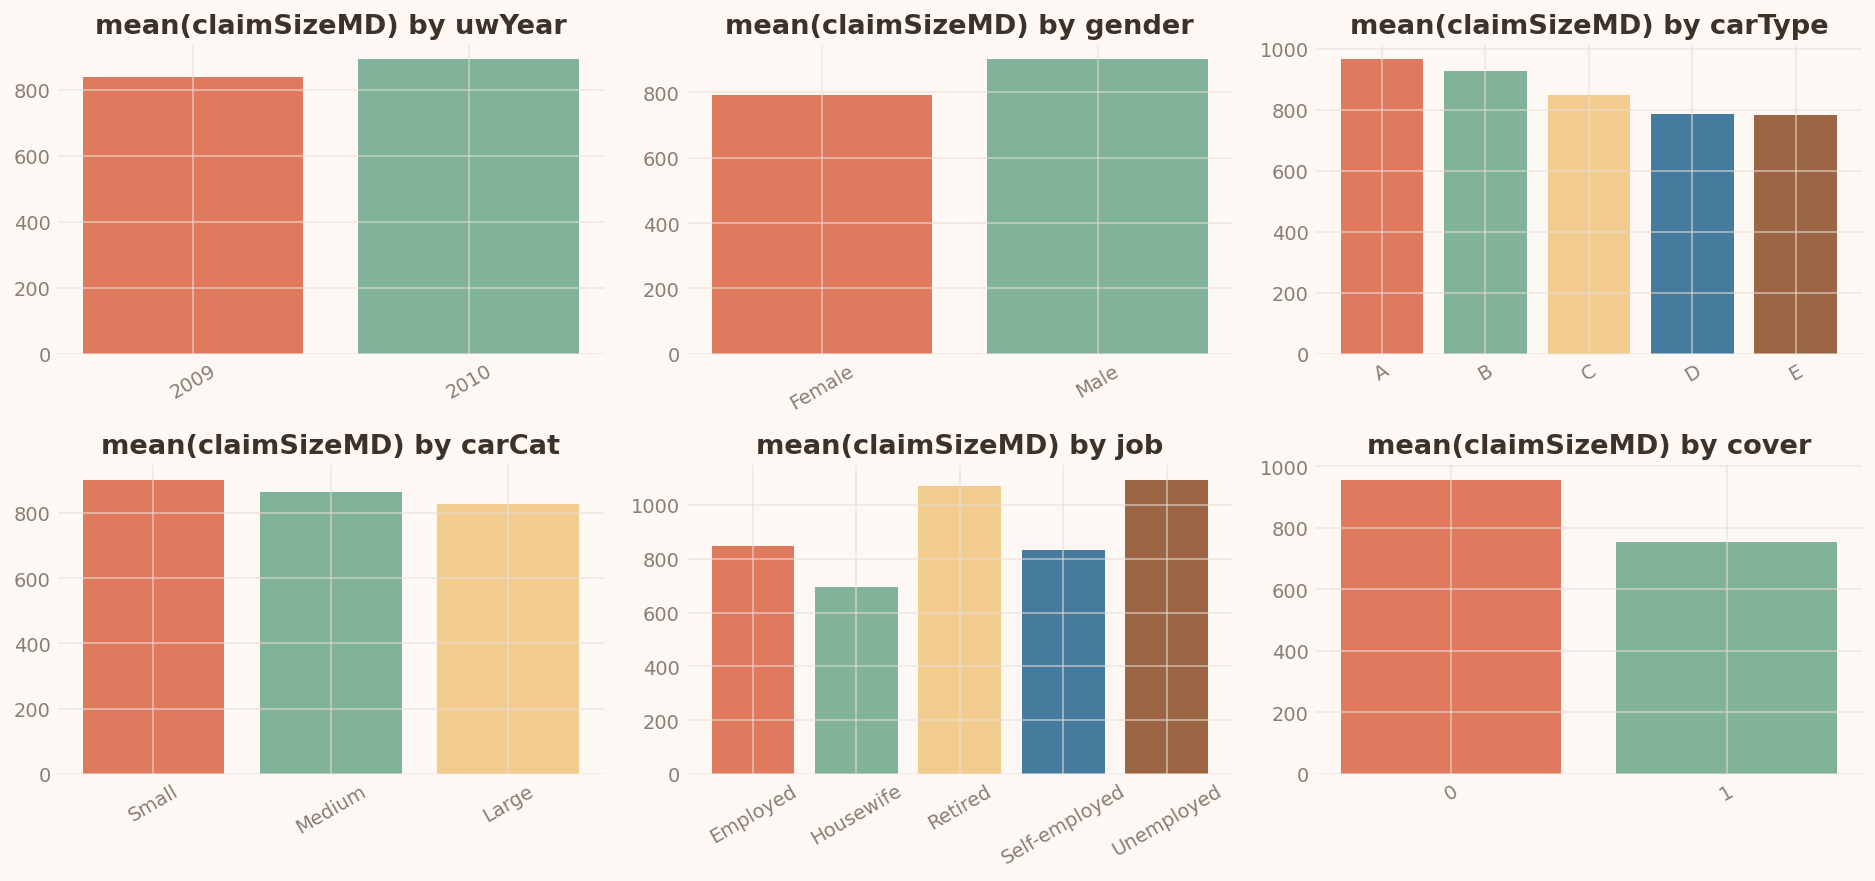

In [11]:
fig = eda.plot_categorical_target(sev_df, SEV_TARGET); plt.show()

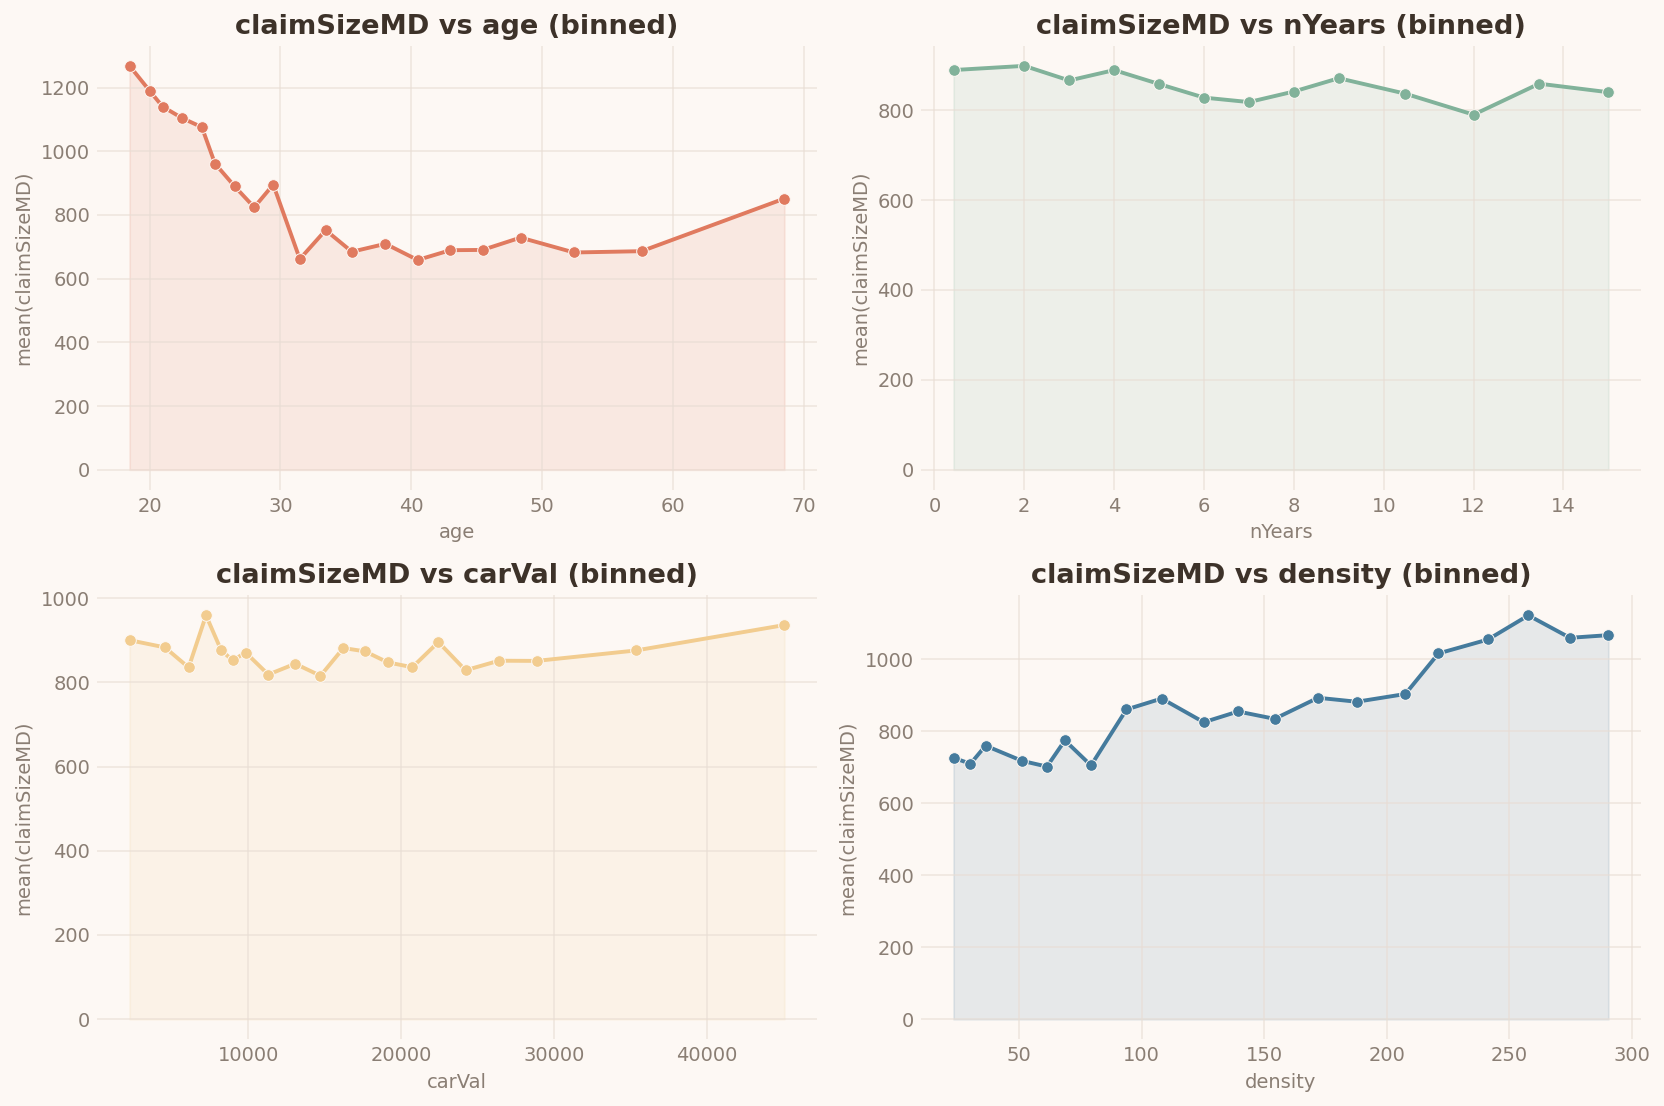

In [12]:
fig = eda.plot_numeric_target(sev_df, SEV_TARGET); plt.show()

**EDA takeaways:**

- **Frequency** is roughly balanced (~50% claim rate). Age, density, and
  job are strong movers. Retired drivers claim much less often; unemployed
  and young drivers claim more.
- **Severity** has a median around 563 EUR but a long right tail (max ~13k).
  Retired and unemployed drivers have the highest average cost when they
  *do* claim — the opposite pattern to frequency for retirees.
- Numeric trends are smooth enough that the GLM linear-in-link assumption
  should hold as a first cut.

---
## 2. Frequency-Severity Models

We fit each component separately using `statsmodels` GLMs (coefficient
p-values and CIs out of the box). 80/20 train-test splits for evaluation.

### 2.1 Frequency — Logistic GLM (Bernoulli, logit link)

The target is binary (claim yes/no), so a logistic regression is the
natural fit. We stratify the split on the target to preserve class balance.

In [13]:
X_tr, X_te, y_tr, y_te = preprocessing.split_xy(
    freq_df, FREQ_TARGET, stratify_target=True,
)
print(f"train: {X_tr.shape}  |  test: {X_te.shape}")

freq_fit = frequency_model.fit_logit(X_tr, y_tr)
print(freq_fit.summary().tables[0])

train: (19819, 17)  |  test: (4955, 17)
                 Generalized Linear Model Regression Results                  
Dep. Variable:            claimNumbMD   No. Observations:                19819
Model:                            GLM   Df Residuals:                    19801
Model Family:                Binomial   Df Model:                           17
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -12646.
Date:                Sun, 26 Apr 2026   Deviance:                       25293.
Time:                        23:48:49   Pearson chi2:                 1.99e+04
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1042
Covariance Type:            nonrobust                                         


In [14]:
freq_metrics = frequency_model.evaluate_frequency(freq_fit, X_te, y_te)
pd.Series(freq_metrics, name="frequency").round(4)

auc              0.6894
log_loss         0.6363
brier            0.2229
mean_pred        0.4936
observed_rate    0.4955
Name: frequency, dtype: float64

In [15]:
freq_coef = frequency_model.coefficient_table(freq_fit)
freq_coef.sort_values("p_value").round(4)

,coef,std_err,z,p_value,ci_low,ci_high,odds_ratio
age,-0.0303,0.0014,-22.1599,0.0000,-0.0330,-0.0276,0.9701
density,0.0039,0.0002,21.1203,0.0000,0.0035,0.0043,1.0039
job_Retired,-0.6671,0.0735,-9.0804,0.0000,-0.8111,-0.5231,0.5132
carType_E,0.3648,0.0462,7.9031,0.0000,0.2744,0.4553,1.4403
gender_Male,0.2493,0.0317,7.8769,0.0000,0.1873,0.3114,1.2832
nYears,-0.0234,0.0033,-7.1117,0.0000,-0.0299,-0.0170,0.9768
carType_D,0.2620,0.0442,5.9225,0.0000,0.1753,0.3487,1.2995
job_Housewife,0.2264,0.0416,5.4365,0.0000,0.1448,0.3080,1.2540
job_Unemployed,0.2152,0.0440,4.8881,0.0000,0.1289,0.3015,1.2401
carVal,0.0000,0.0000,4.7832,0.0000,0.0000,0.0000,1.0000


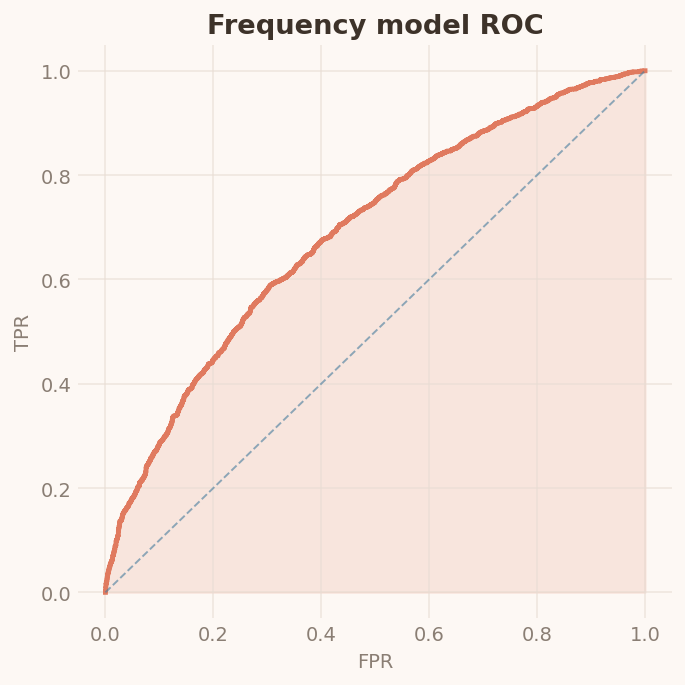

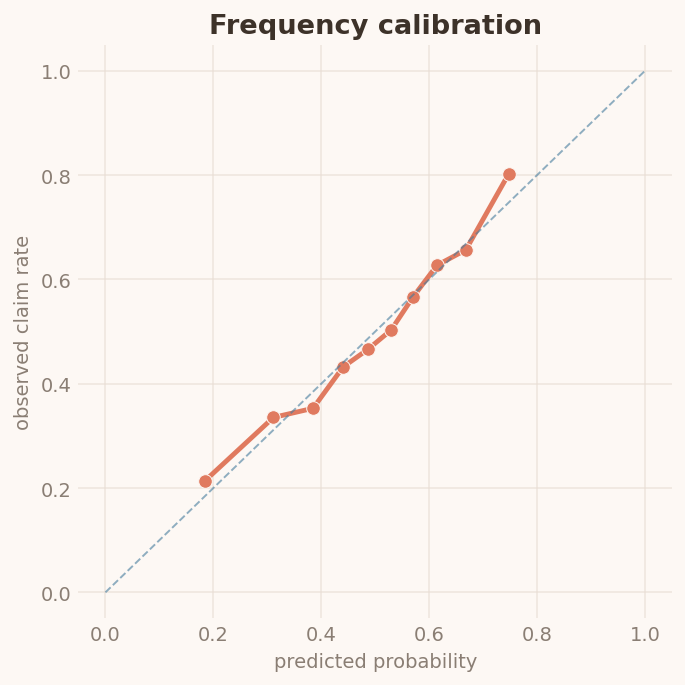

In [16]:
y_pred_freq = frequency_model.predict_proba(freq_fit, X_te)
fig1 = plots.plot_roc(y_te, y_pred_freq); plt.show()
fig2 = plots.plot_calibration(y_te, y_pred_freq); plt.show()

**Frequency takeaways:** AUC ~0.69, well-calibrated (predicted mean
tracks observed rate). Significant drivers: `age` (older → fewer claims),
`density` (urban → more claims), `job_Retired` (OR ~0.51), `carType_E`
(OR ~1.44), `gender_Male` (OR ~1.28).

### 2.2 Severity — Gamma GLM (log link)

Claim costs are positive and right-skewed; the Gamma family with log link
is the standard actuarial choice. The log link gives multiplicative effects
that combine naturally with the frequency model.

In [17]:
Xs_tr, Xs_te, ys_tr, ys_te = preprocessing.split_xy(sev_df, SEV_TARGET)
print(f"train: {Xs_tr.shape}  |  test: {Xs_te.shape}")

sev_fit = severity_model.fit_gamma_glm(Xs_tr, ys_tr)
print(sev_fit.summary().tables[0])

train: (9801, 17)  |  test: (2451, 17)
                 Generalized Linear Model Regression Results                  
Dep. Variable:            claimSizeMD   No. Observations:                 9801
Model:                            GLM   Df Residuals:                     9783
Model Family:                   Gamma   Df Model:                           17
Link Function:                    Log   Scale:                          1.0630
Method:                          IRLS   Log-Likelihood:                -75667.
Date:                Sun, 26 Apr 2026   Deviance:                       11465.
Time:                        23:48:49   Pearson chi2:                 1.04e+04
No. Iterations:                    14   Pseudo R-squ. (CS):            0.08348
Covariance Type:            nonrobust                                         


In [18]:
sev_metrics = severity_model.evaluate_severity(sev_fit, Xs_te, ys_te)
pd.Series(sev_metrics, name="severity").round(4)

mae              634.2401
rmse             907.3237
mean_pred        869.2930
observed_mean    861.3003
rank_corr         -0.0140
Name: severity, dtype: float64

In [19]:
sev_coef = severity_model.coefficient_table(sev_fit)
sev_coef.sort_values("p_value").round(4)

,coef,std_err,z,p_value,ci_low,ci_high,mult_effect
const,6.9606,0.0507,137.2741,0.0000,6.8612,7.0600,1054.2978
age,-0.0131,0.0009,-13.9431,0.0000,-0.0149,-0.0112,0.9870
density,0.0016,0.0001,13.0923,0.0000,0.0014,0.0019,1.0016
job_Retired,0.6536,0.0631,10.3648,0.0000,0.5300,0.7772,1.9225
job_Unemployed,0.2210,0.0291,7.5860,0.0000,0.1639,0.2781,1.2473
carType_E,-0.2376,0.0316,-7.5272,0.0000,-0.2995,-0.1757,0.7885
carType_D,-0.2143,0.0309,-6.9327,0.0000,-0.2749,-0.1537,0.8071
gender_Male,0.1394,0.0224,6.2138,0.0000,0.0954,0.1833,1.1495
cover_1,-0.1305,0.0217,-6.0142,0.0000,-0.1730,-0.0880,0.8777
job_Housewife,-0.1229,0.0281,-4.3726,0.0000,-0.1780,-0.0678,0.8844


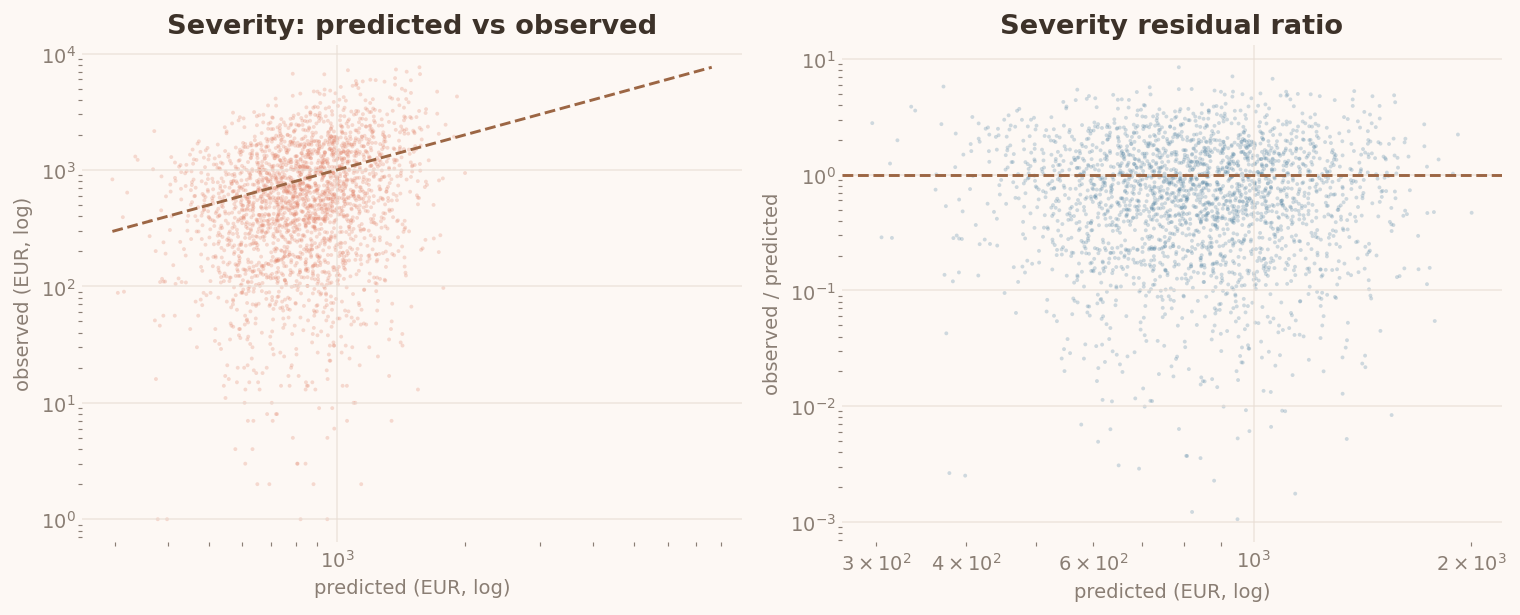

In [20]:
y_pred_sev = severity_model.predict_mean(sev_fit, Xs_te)
fig = plots.plot_severity_diagnostics(ys_te, y_pred_sev); plt.show()

**Severity takeaways:** Mean predicted cost tracks the observed mean
(balanced). Individual predictions are noisy (as expected — claim size
variability is inherent). Notable cross-effect: `carType_E` *increases*
frequency but *decreases* severity; retirees claim *rarely* but *expensively*.
This is exactly why the two-model decomposition matters.

---
## 3. Pure Premium & Portfolio Calibration

We score every policy in the frequency dataset (the full portfolio) to get
$\widehat{\text{PP}} = \hat{p} \times \hat{\mu}$, then run a
**balance-property check**: does the predicted total loss approximate the
observed total in the severity dataset?

### 3.1 Computing per-policy pure premium

In [21]:
X_freq_full = preprocessing.build_design_matrix(freq_df)
X_sev_full  = preprocessing.build_design_matrix(sev_df)
sev_columns = list(X_sev_full.columns)

pp_df = pure_premium.compute_pure_premium(
    X_freq_full, freq_fit, sev_fit, sev_columns=sev_columns,
)
pp_df.describe().round(2)

,p_claim,exp_severity,pure_premium
count,24774.00,24774.00,24774.00
mean,0.50,833.03,428.29
std,0.16,253.14,232.46
min,0.06,262.67,40.80
25%,0.39,648.15,254.24
50%,0.51,797.77,384.70
75%,0.62,982.92,558.09
max,0.88,2060.26,1670.10


### 3.2 Balance-property check

In [22]:
calib = pure_premium.calibration_check(
    pp_df, observed_total_loss=sev_df[SEV_TARGET].sum(),
)
pd.Series(calib).round(2)

predicted_total_loss    10610577.59
observed_total_loss     10615726.00
ratio_pred_over_obs            1.00
dtype: float64

### 3.3 Loss distribution and concentration

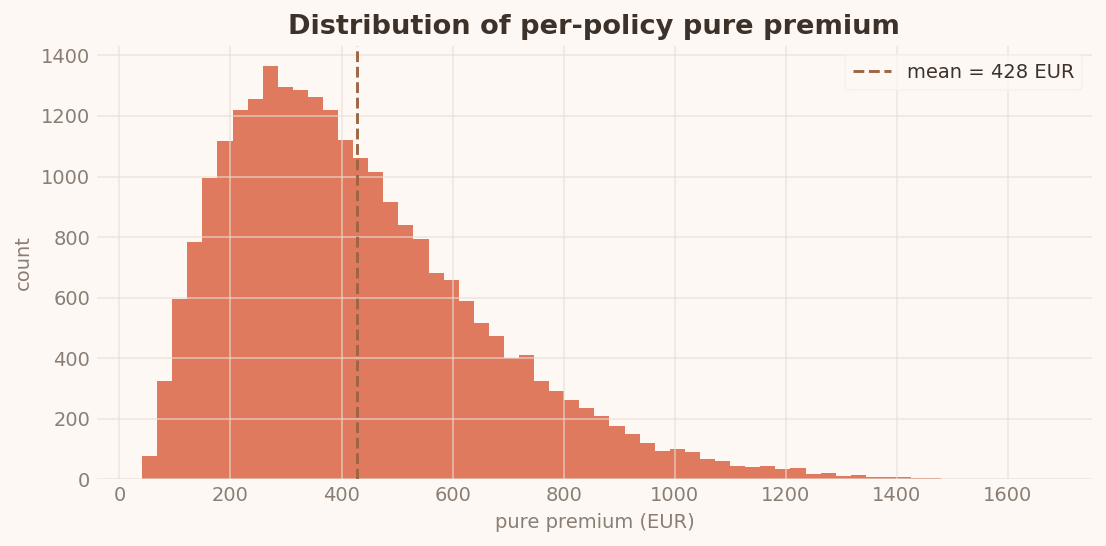

In [23]:
fig = plots.plot_pure_premium_distribution(pp_df); plt.show()

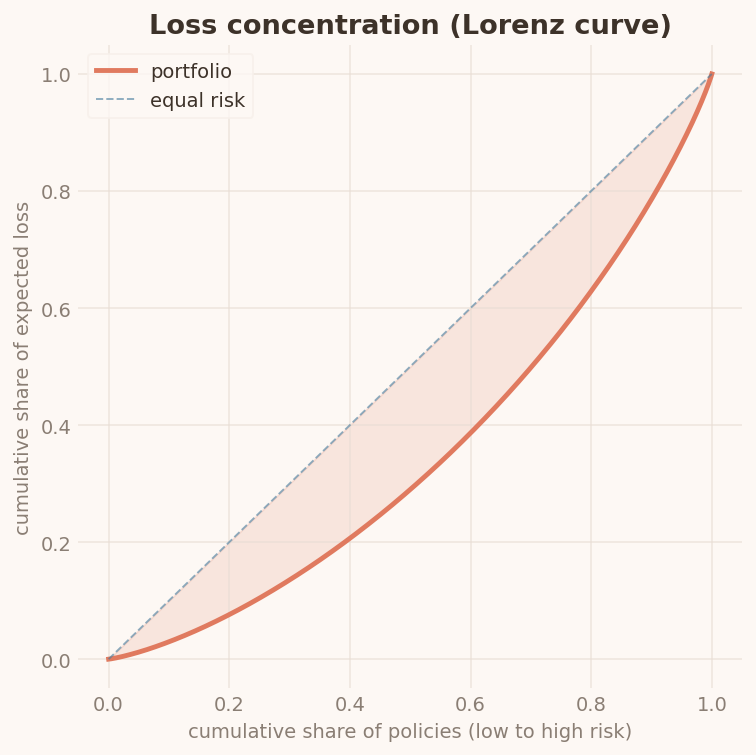

In [24]:
fig = plots.plot_lorenz(pp_df); plt.show()

**Calibration & concentration:** The predicted-to-observed ratio is ~1.0 —
the combined model is well-balanced at portfolio level. The Lorenz curve
shows meaningful risk concentration: a small share of policies drives a
disproportionate share of expected loss.

---
## 4. Customer Profiling & Recommendations

We define four risk tiers by pure-premium quantile:

| Tier | Quantile range | Interpretation |
|---|---|---|
| Low | bottom 50% | Profitable, retain |
| Medium | 50–80% | Average, monitor |
| High | 80–95% | Above average, consider repricing |
| **Very High** | **top 5%** | **Unprofitable, action required** |

### 4.1 Risk-tier summary

In [25]:
tiers = profiling.assign_tiers(pp_df)
tier_tbl = profiling.tier_summary(freq_df, pp_df, tiers)
tier_tbl.round(2)

,n,mean_pp,median_pp,mean_age,mean_carVal,mean_density,pct_of_portfolio,pct_of_total_loss
tier,,,,,,,,
Low,12387,248.31,254.23,47.30,16311.14,91.59,50.0,28.99
Medium,7432,484.00,478.34,32.37,17046.47,137.70,30.0,33.90
High,3716,716.48,706.04,26.86,17360.86,188.46,15.0,25.09
Very High,1239,1029.25,992.98,23.33,17974.21,236.92,5.0,12.02


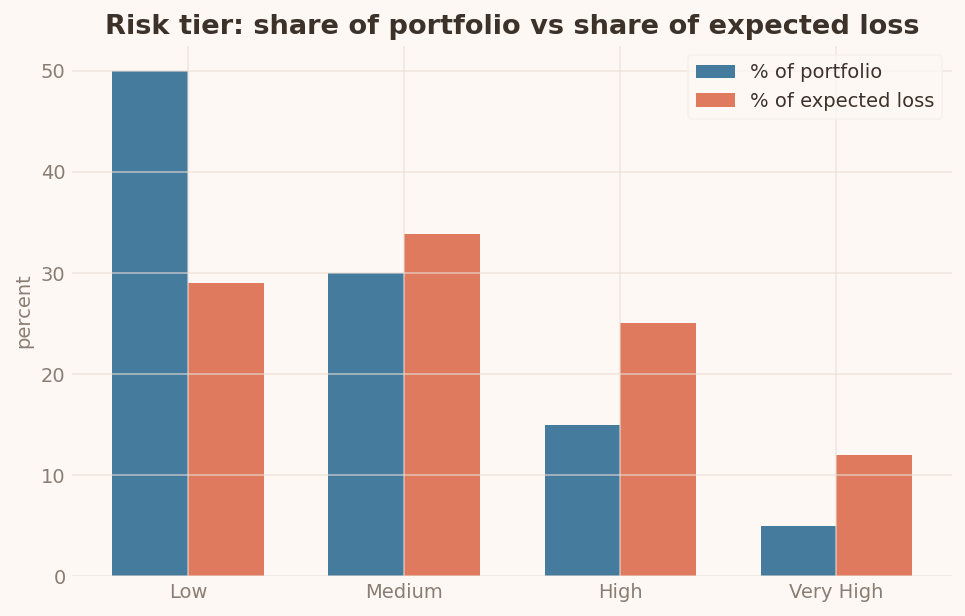

In [26]:
fig = plots.plot_tier_bars(tier_tbl); plt.show()

### 4.2 Profile of the unprofitable segment

In [27]:
top_profile = profiling.describe_top_segment(
    freq_df, pp_df, tiers, segment_label="Very High",
)
top_profile

{'segment': 'Very High',
 'n_policies': 1239,
 'share_of_portfolio_pct': 5.0,
 'mean_pure_premium': 1029.25,
 'ratio_to_overall_mean': 2.4,
 'typical_profile': {'uwYear': '2010 (61%)',
  'gender': 'Male (86%)',
  'carType': 'A (36%)',
  'carCat': 'Small (43%)',
  'job': 'Unemployed (62%)',
  'cover': '0 (86%)',
  'age': 23.3,
  'nYears': 4.0,
  'carVal': 17974.2,
  'density': 236.9}}

### 4.3 Factor-level breakdown across tiers

In [28]:
for f in ["gender", "carType", "carCat", "job", "cover", "uwYear"]:
    print(f"\n--- {f} (% of each tier) ---")
    print(profiling.tier_factor_profile(freq_df, tiers, f))


--- gender (% of each tier) ---
              Female  Male
pure_premium              
Low             42.0  58.0
Medium          30.2  69.8
High            23.0  77.0
Very High       14.2  85.8

--- carType (% of each tier) ---
                 A     B     C     D     E
pure_premium                              
Low           25.8  19.7  14.3  22.0  18.2
Medium        25.1  21.5  13.8  20.8  18.8
High          27.6  24.5  13.9  17.8  16.2
Very High     36.1  26.9  12.8  12.3  11.9

--- carCat (% of each tier) ---
              Small  Medium  Large
pure_premium                      
Low            23.0    36.5   40.5
Medium         36.3    37.1   26.7
High           40.8    36.7   22.5
Very High      42.7    36.2   21.1

--- job (% of each tier) ---
              Employed  Housewife  Retired  Self-employed  Unemployed
pure_premium                                                         
Low               28.5       24.6     15.9           24.3         6.7
Medium            39.8       2

### 4.4 Recommendations to management

> **Definition used:** A customer profile is *unprofitable* if its predicted
> pure premium significantly exceeds the portfolio average. Without premium
> data, this is the cleanest pure-risk proxy available.

**Actions at renewal:**

1. **Reprice the Very High tier** — their expected loss is ~2.4x the book
   average. Current pricing almost certainly doesn't reflect that.
2. **Adjust coverage on selected profiles** — raise deductibles or restrict
   MD cover for the worst micro-segments (young, urban, unemployed males).
3. **Monitor the High tier** — not the worst offenders individually, but at
   15% of the portfolio a small repricing compounds to significant savings.

**Caveats:**

- No premium data → "unprofitable" is relative, not absolute.
- Frequency and severity are modelled on disjoint datasets; we assume the
  same covariate relationships hold in unseen no-claim records.
- A gradient-boosting robustness check would strengthen conclusions.